In [52]:
import pandas as pd
from IPython.display import display
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import r2_score, f1_score
from sklearn.metrics import precision_score, recall_score

In [53]:
df = pd.read_csv('datasets/Sleep_health_and_lifestyle_dataset_processed.csv')
display(df.head(2))


,person_id,gender,age,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,heart_rate,daily_steps,...,occupation_Lawyer,occupation_Manager,occupation_Nurse,occupation_Sales Representative,occupation_Salesperson,occupation_Scientist,occupation_Software Engineer,occupation_Teacher,systolic,diastolic
0,1,1,-1.753096,-1.298887,-1.09828,-0.825418,0.347021,1,1.654719,-1.619584,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.330002,-0.268102
1,2,1,-1.637643,-1.173036,-1.09828,0.039844,1.475592,0,1.170474,1.970077,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.459239,-0.755640


In [54]:
display(df.info)

<bound method DataFrame.info of      person_id  gender       age  sleep_duration  quality_of_sleep  \
0            1       1 -1.753096       -1.298887         -1.098280   
1            2       1 -1.637643       -1.173036         -1.098280   
2            3       1 -1.637643       -1.173036         -1.098280   
3            4       1 -1.637643       -1.550588         -2.771424   
4            5       1 -1.637643       -1.550588         -2.771424   
..         ...     ...       ...             ...               ...   
369        370       0  1.941401        1.218127          1.411435   
370        371       0  1.941401        1.092276          1.411435   
371        372       0  1.941401        1.218127          1.411435   
372        373       0  1.941401        1.218127          1.411435   
373        374       0  1.941401        1.218127          1.411435   

     physical_activity_level  stress_level  bmi_category  heart_rate  \
0                  -0.825418      0.347021             

# Разделение выборки на обучающую и тестовую


In [55]:
X_disorder = df.drop(['sleep_disorder', 'person_id'], axis=1)
y_disorder = df['sleep_disorder']

X_quality = df.drop(['quality_of_sleep', 'person_id'], axis=1)
y_quality = df['quality_of_sleep']

X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(X_quality, y_quality, test_size=0.2, random_state=42, stratify=y_quality)
X_train_classification, X_test_classification, y_train_classification, y_test_classification = train_test_split(X_disorder, y_disorder, test_size=0.2, random_state=42, stratify=y_disorder)


In [56]:
print("Обучающая выборка классификации:")
print(y_train_classification.value_counts())
print("Тестовая выборка классификации:")
print(y_test_classification.value_counts())

Обучающая выборка классификации:
sleep_disorder
1    175
2     62
0     62
Name: count, dtype: int64
Тестовая выборка классификации:
sleep_disorder
1    44
2    16
0    15
Name: count, dtype: int64


In [57]:
print("Обучающая выборка регрессии:")
print(y_train_regression.value_counts())
print("Тестовая выборка регрессии:")
print(y_test_regression.value_counts())


Обучающая выборка регрессии:
quality_of_sleep
 0.574864    87
-1.098280    84
-0.261708    61
 1.411435    57
-1.934852     6
-2.771424     4
Name: count, dtype: int64
Тестовая выборка регрессии:
quality_of_sleep
 0.574864    22
-1.098280    21
-0.261708    16
 1.411435    14
-2.771424     1
-1.934852     1
Name: count, dtype: int64


# Линейные модели (регрессия и классификация)

### Логистическая регрессия

In [58]:
# Создание и обучение логистической регрессии для задачи классификации
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_classification, y_train_classification)

# Предсказание на тестовой выборке
y_pred_logistic_classification = logistic_model.predict(X_test_classification)

# Оценка точности модели
accuracy_logistic_classification = accuracy_score(y_test_classification, y_pred_logistic_classification)
print(f"Точность логистической регрессии: {accuracy_logistic_classification:.2f}")

# Отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_classification, y_pred_logistic_classification))


Точность логистической регрессии: 0.95
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       1.00      0.98      0.99        44
           2       0.84      1.00      0.91        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75



### Полиномиальная регрессия

In [59]:
# Создаем полиномиальные признаки степени 2
polynomial_features = PolynomialFeatures(degree=2, include_bias=False)

# Создаем модель линейной регрессии
linear_regression = LinearRegression()

# Создаем пайплайн, который сначала преобразует данные в полиномиальные признаки, а затем применяет линейную регрессию
polynomial_regression_model = make_pipeline(polynomial_features, linear_regression)

# Обучаем модель на обучающей выборке
polynomial_regression_model.fit(X_train_regression, y_train_regression)

# Предсказание на тестовой выборке
y_pred_regression_polynomial = polynomial_regression_model.predict(X_test_regression)

# Оценка модели с использованием среднеквадратичной ошибки
mse = mean_squared_error(y_test_regression, y_pred_regression_polynomial)
print(f"Среднеквадратичная ошибка полиномиальной регрессии: {mse:.2f}")


Среднеквадратичная ошибка полиномиальной регрессии: 0.09


# SVM

In [60]:
# Создаем модель SVM
svm_model = SVC(kernel='linear')

# Обучаем модель на обучающей выборке
svm_model.fit(X_train_classification, y_train_classification)

# Предсказание на тестовой выборке
y_pred_svm = svm_model.predict(X_test_classification)

# Оценка точности модели
accuracy_svm = accuracy_score(y_test_classification, y_pred_svm)
print(f"Точность SVM: {accuracy_svm:.2f}")

# Отчет о классификации
print("Отчет о классификации для SVM:")
print(classification_report(y_test_classification, y_pred_svm))



Точность SVM: 0.95
Отчет о классификации для SVM:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        15
           1       1.00      0.98      0.99        44
           2       0.80      1.00      0.89        16

    accuracy                           0.95        75
   macro avg       0.93      0.93      0.92        75
weighted avg       0.96      0.95      0.95        75



# SVR

In [61]:
# Создаем модель SVR
svr_model = SVR(kernel='linear')

# Обучаем модель на обучающей выборке
svr_model.fit(X_train_regression, y_train_regression)

# Предсказание на тестовой выборке
y_pred_svr = svr_model.predict(X_test_regression)

# Оценка модели с использованием среднеквадратичной ошибки
mse_svr = mean_squared_error(y_test_regression, y_pred_svr)
print(f"Среднеквадратичная ошибка SVR: {mse_svr:.2f}")


Среднеквадратичная ошибка SVR: 0.06


# Дерево решений

In [62]:
# Модель дерева решений для регрессии
decision_tree_regressor = DecisionTreeRegressor()

# Обучаем модель на обучающей выборке
decision_tree_regressor.fit(X_train_regression, y_train_regression)

# Предсказание на тестовой выборке
y_pred_tree_regression = decision_tree_regressor.predict(X_test_regression)

# Оценка модели с использованием среднеквадратичной ошибки
mse_tree = mean_squared_error(y_test_regression, y_pred_tree_regression)
print(f"Среднеквадратичная ошибка дерева решений для регрессии: {mse_tree:.2f}")

# Модель дерева решений для классификации
decision_tree_classifier = DecisionTreeClassifier()

# Обучаем модель на обучающей выборке
decision_tree_classifier.fit(X_train_classification, y_train_classification)

# Предсказание на тестовой выборке
y_pred_tree_classification = decision_tree_classifier.predict(X_test_classification)

# Оценка точности модели
accuracy_tree = accuracy_score(y_test_classification, y_pred_tree_classification)
print(f"Точность дерева решений для классификации: {accuracy_tree:.2f}")

# Отчет о классификации
print("Отчет о классификации для дерева решений:")
print(classification_report(y_test_classification, y_pred_tree_classification))

Среднеквадратичная ошибка дерева решений для регрессии: 0.04
Точность дерева решений для классификации: 0.91
Отчет о классификации для дерева решений:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        15
           1       1.00      0.95      0.98        44
           2       0.81      0.81      0.81        16

    accuracy                           0.91        75
   macro avg       0.86      0.88      0.87        75
weighted avg       0.91      0.91      0.91        75



# Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.

In [63]:
# Оценка качества линейной модели
mse_linear = mean_squared_error(y_test_regression, y_pred_regression_polynomial)
r2_linear = r2_score(y_test_regression, y_pred_regression_polynomial)
print(f"Среднеквадратичная ошибка линейной модели: {mse_linear:.2f}")
print(f"Коэффициент детерминации (R^2) линейной модели: {r2_linear:.2f}")

# Оценка качества модели дерева решений
mse_tree = mean_squared_error(y_test_regression, y_pred_tree_regression)
r2_tree = r2_score(y_test_regression, y_pred_tree_regression)
print(f"Среднеквадратичная ошибка дерева решений: {mse_tree:.2f}")
print(f"Коэффициент детерминации (R^2) дерева решений: {r2_tree:.2f}")

# Оценка качества модели SVR
mse_svr = mean_squared_error(y_test_regression, y_pred_svr)
r2_svr = r2_score(y_test_regression, y_pred_svr)
print(f"Среднеквадратичная ошибка SVR: {mse_svr:.2f}")
print(f"Коэффициент детерминации (R^2) SVR: {r2_svr:.2f}")


# Сравнение моделей
print("\nСравнение моделей:")
if mse_linear < mse_tree and mse_linear < mse_svr:
    print("Линейная модель имеет меньшую среднеквадратичную ошибку.")
elif mse_tree < mse_svr:
    print("Дерево решений имеет меньшую среднеквадратичную ошибку.")
else:
    print("SVR имеет меньшую среднеквадратичную ошибку.")

if r2_linear > r2_tree and r2_linear > r2_svr:
    print("Линейная модель имеет более высокий коэффициент детерминации.")
elif r2_tree > r2_svr:
    print("Дерево решений имеет более высокий коэффициент детерминации.")
else:
    print("SVR имеет более высокий коэффициент детерминации.")


Среднеквадратичная ошибка линейной модели: 0.09
Коэффициент детерминации (R^2) линейной модели: 0.91
Среднеквадратичная ошибка дерева решений: 0.04
Коэффициент детерминации (R^2) дерева решений: 0.96
Среднеквадратичная ошибка SVR: 0.06
Коэффициент детерминации (R^2) SVR: 0.94

Сравнение моделей:
Дерево решений имеет меньшую среднеквадратичную ошибку.
Дерево решений имеет более высокий коэффициент детерминации.


In [64]:
# Оценка качества модели дерева решений
precision_tree = precision_score(y_test_classification, y_pred_tree_classification, average='weighted')
recall_tree = recall_score(y_test_classification, y_pred_tree_classification, average='weighted')
f1_tree = f1_score(y_test_classification, y_pred_tree_classification, average='weighted')
print(f"Точность (Precision) дерева решений: {precision_tree:.2f}")
print(f"Полнота (Recall) дерева решений: {recall_tree:.2f}")
print(f"F1-мера дерева решений: {f1_tree:.2f}")

# Оценка качества модели линейного SVM
y_pred_svm_classification = svm_model.predict(X_test_classification)
precision_svm = precision_score(y_test_classification, y_pred_svm_classification, average='weighted')
recall_svm = recall_score(y_test_classification, y_pred_svm_classification, average='weighted')
f1_svm = f1_score(y_test_classification, y_pred_svm_classification, average='weighted')
print(f"Точность (Precision) линейного SVM: {precision_svm:.2f}")
print(f"Полнота (Recall) линейного SVM: {recall_svm:.2f}")
print(f"F1-мера линейного SVM: {f1_svm:.2f}")

# Оценка качества модели логистической регрессии
y_pred_logistic_classification = logistic_model.predict(X_test_classification)
precision_logistic = precision_score(y_test_classification, y_pred_logistic_classification, average='weighted')
recall_logistic = recall_score(y_test_classification, y_pred_logistic_classification, average='weighted')
f1_logistic = f1_score(y_test_classification, y_pred_logistic_classification, average='weighted')
print(f"Точность (Precision) логистической регрессии: {precision_logistic:.2f}")
print(f"Полнота (Recall) логистической регрессии: {recall_logistic:.2f}")
print(f"F1-мера логистической регрессии: {f1_logistic:.2f}")

# Сравнение моделей
print("\nСравнение моделей классификации:")
if precision_tree > precision_svm and precision_tree > precision_logistic:
    print("Дерево решений имеет более высокую точность (Precision).")
elif precision_svm > precision_logistic:
    print("Линейный SVM имеет более высокую точность (Precision).")
else:
    print("Логистическая регрессия имеет более высокую точность (Precision).")

if recall_tree > recall_svm and recall_tree > recall_logistic:
    print("Дерево решений имеет более высокую полноту (Recall).")
elif recall_svm > recall_logistic:
    print("Линейный SVM имеет более высокую полноту (Recall).")
else:
    print("Логистическая регрессия имеет более высокую полноту (Recall).")

if f1_tree > f1_svm and f1_tree > f1_logistic:
    print("Дерево решений имеет более высокую F1-меру.")
elif f1_svm > f1_logistic:
    print("Линейный SVM имеет более высокую F1-меру.")
else:
    print("Логистическая регрессия имеет более высокую F1-меру.")


Точность (Precision) дерева решений: 0.91
Полнота (Recall) дерева решений: 0.91
F1-мера дерева решений: 0.91
Точность (Precision) линейного SVM: 0.96
Полнота (Recall) линейного SVM: 0.95
F1-мера линейного SVM: 0.95
Точность (Precision) логистической регрессии: 0.95
Полнота (Recall) логистической регрессии: 0.95
F1-мера логистической регрессии: 0.95

Сравнение моделей классификации:
Линейный SVM имеет более высокую точность (Precision).
Логистическая регрессия имеет более высокую полноту (Recall).
Линейный SVM имеет более высокую F1-меру.


# Постройте график, показывающий важность признаков в дереве решений.

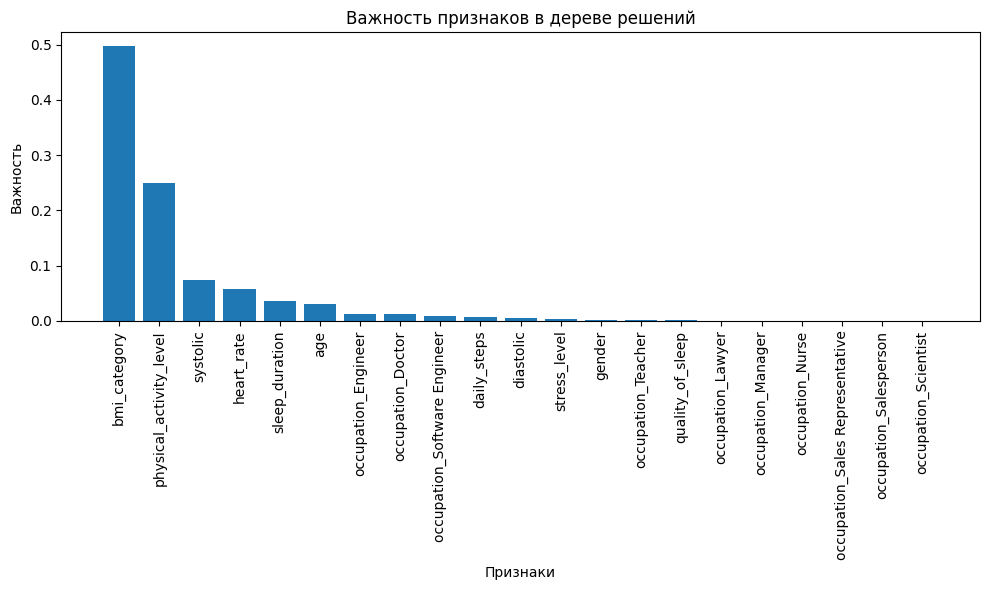

In [65]:
import matplotlib.pyplot as plt
import numpy as np

feature_importances = decision_tree_classifier.feature_importances_

plt.figure(figsize=(10, 6))
indices = np.argsort(feature_importances)[::-1]
plt.bar(range(len(feature_importances)), feature_importances[indices], align='center')
plt.xticks(range(len(feature_importances)), np.array(X_train_classification.columns)[indices], rotation=90)
plt.title('Важность признаков в дереве решений')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.tight_layout()
plt.show()


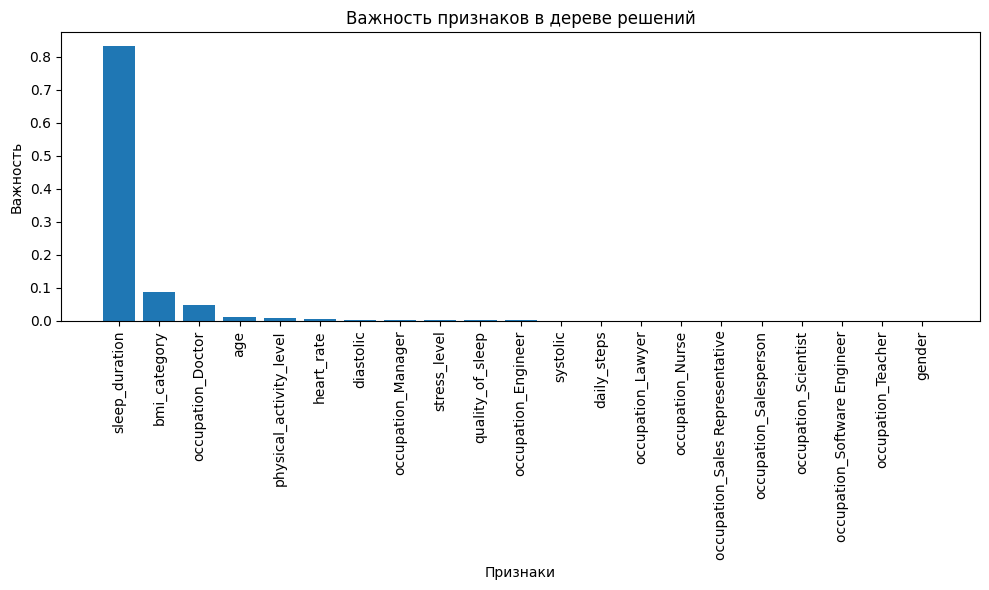

In [66]:
import matplotlib.pyplot as plt
import numpy as np

feature_importances = decision_tree_regressor.feature_importances_

plt.figure(figsize=(10, 6))
indices = np.argsort(feature_importances)[::-1]
plt.bar(range(len(feature_importances)), feature_importances[indices], align='center')
plt.xticks(range(len(feature_importances)), np.array(X_train_classification.columns)[indices], rotation=90)
plt.title('Важность признаков в дереве решений')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

# Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.

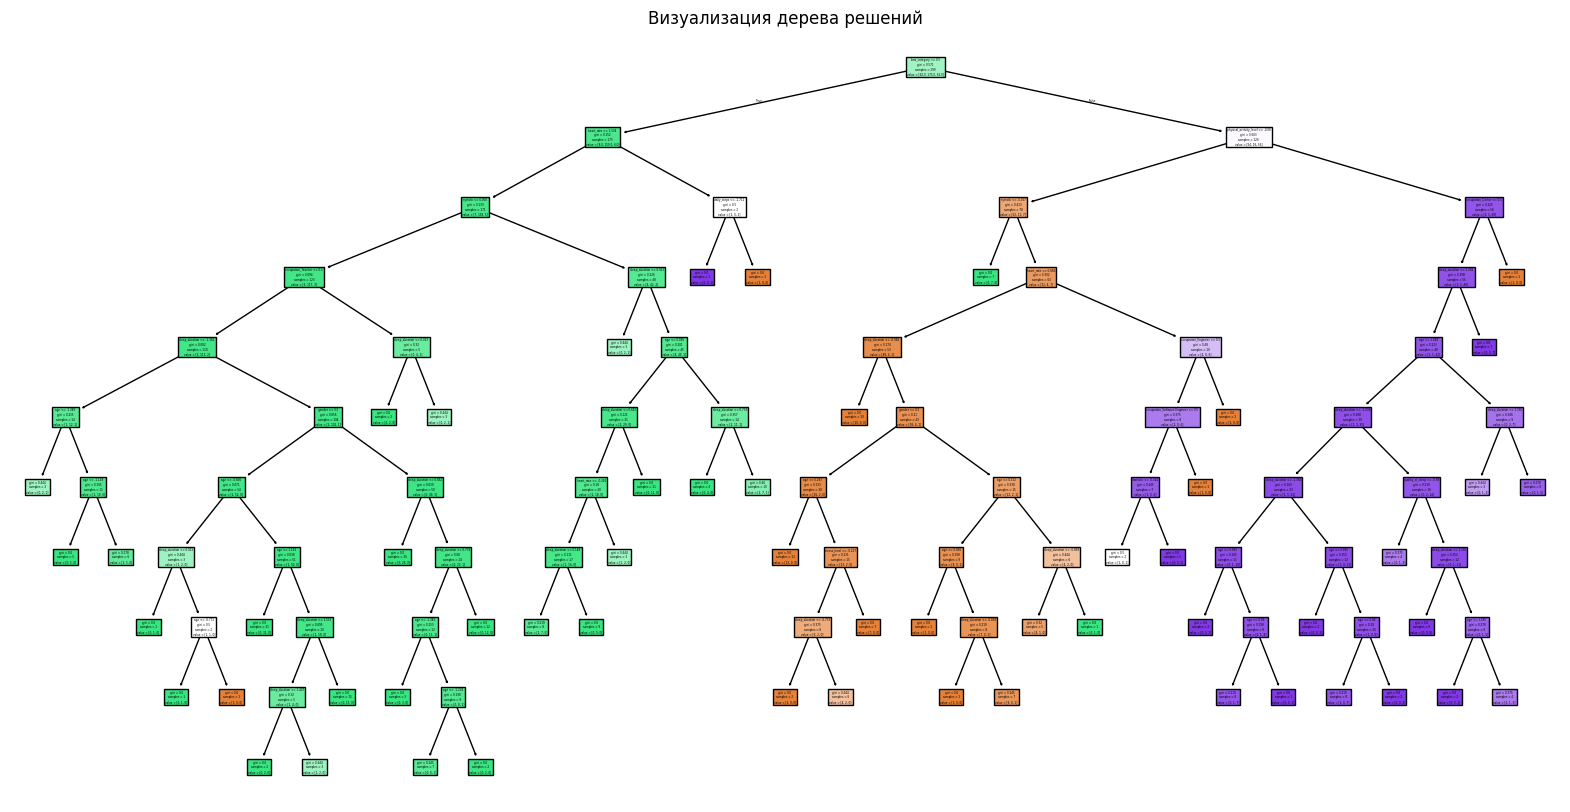

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(decision_tree_classifier, feature_names=list(X_train_classification.columns), filled=True)
plt.title('Визуализация дерева решений')
plt.show()


In [68]:
from sklearn.tree import export_text

tree_rules = export_text(decision_tree_classifier, feature_names=list(X_train_classification.columns))
print(tree_rules)


|--- bmi_category <= 0.50
|   |--- heart_rate <= 1.53
|   |   |--- systolic <= 0.06
|   |   |   |--- occupation_Teacher <= 0.50
|   |   |   |   |--- sleep_duration <= -1.36
|   |   |   |   |   |--- age <= -1.35
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- age >  -1.35
|   |   |   |   |   |   |--- age <= -1.12
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- age >  -1.12
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- sleep_duration >  -1.36
|   |   |   |   |   |--- gender <= 0.50
|   |   |   |   |   |   |--- age <= -0.66
|   |   |   |   |   |   |   |--- sleep_duration <= 0.02
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- sleep_duration >  0.02
|   |   |   |   |   |   |   |   |--- age <= -0.77
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- age >  -0.77
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- age >  -0.66
|   |   |   |   | 